# Reviewer-driven revision: stronger GAN attack for RUIP-BA voice data (unknown-$R$ scenario)

This notebook is a standalone reimplementation of the voice-data attack experiment using the same oversampled dataset and the same user split used in `Final_DACGANUnKnownRPDP.ipynb`, but it explicitly addresses the reviewer concern that the original Table 7 GAN may underestimate privacy risk.

**Axiom 1 (same data regime).** Let the oversampled voice dataset be
\[
\mathcal{D}=\{(\mathbf{x}_i,u_i)\}_{i=1}^{N}, \qquad \mathbf{x}_i\in\mathbb{R}^{104},\; u_i\in\{0,\dots,85\}.
\]
We preserve the original partition
\[
\mathcal{U}_{\text{train}}=\{0,\dots,67\}, \qquad \mathcal{U}_{\text{aux}}=\{68,\dots,85\},
\]
so that the adversary is trained only on auxiliary users and tested against enrolled users.

**Reviewer-response principle.** Theorem 8 in the manuscript concerns the *optimal* GAN equilibrium, not any single finite network. Therefore, the practical attack benchmark should include a model class that is strictly stronger than the original three-layer, 128-unit generator. In this notebook we compare three inverse models:

1. a DNN regressor baseline,
2. the original Table 7 style GAN (`94 -> 128 -> 128 -> 104` generator), and
3. a stronger GAN with five hidden layers (`256 -> 512 -> 512 -> 256 -> 256`) plus feature-attention gates.

**Proposition 1 (empirical upper-envelope test).** If the stronger attack does not materially improve the recoverability ratio
\[
\rho_u = \frac{1}{d}\sum_{j=1}^{d}\mathbf{1}[p_{u,j}>\alpha], \qquad d=104,
\]
for user $u$, then the privacy claim is more robust against the reviewer concern. The next code cell fixes the runtime configuration, seeds, and reproducibility assumptions needed to test this proposition.

In [101]:
from __future__ import annotations

import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.random_projection import SparseRandomProjection
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass
class Config:
    n_components: int = 94
    epsilon: float = 7.0
    delta: float = 1e-5
    sensitivity: float = 1.0
    batch_size: int = 128
    mlp_epochs: int = 100
    gan_epochs: int = 140
    lr_mlp: float = 1e-3
    lr_gan: float = 2e-4
    lambda_recon: float = 10.0
    alpha: float = 0.05
    max_user_id=155
    training_users: tuple = tuple(range(0, max_user_id))
    knownR=True
    auxiliary_users: tuple = tuple(range(max_user_id, 193))
    output_dir_name: str = "reviewer_revision_outputs"

CFG = Config()
print(CFG)
print("device:", DEVICE)
print("Tip: increase mlp_epochs and gan_epochs to 200 for longer manuscript-style training.")

Config(n_components=94, epsilon=7.0, delta=1e-05, sensitivity=1.0, batch_size=128, mlp_epochs=100, gan_epochs=140, lr_mlp=0.001, lr_gan=0.0002, lambda_recon=10.0, alpha=0.05, training_users=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154), auxiliary_users=(155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

## Data loading, notation, and the preserved train/auxiliary split

**Definition 1 (plain profile matrix).** After loading the oversampled voice data, we form
\[
X \in \mathbb{R}^{n \times d}, \qquad d=104,
\]
where each row is one oversampled voice observation and each label identifies the user that generated it.

**Axiom 2 (review-consistent split).** To preserve the experimental protocol of the original notebook and manuscript, we define
\[
X_{\mathrm{train}} = X\,|\,u \in \mathcal{U}_{\mathrm{train}},
\qquad
X_{\mathrm{aux}} = X\,|\,u \in \mathcal{U}_{\mathrm{aux}}.
\]
The attack models are trained only on $X_{\mathrm{aux}}$ and evaluated on protected versions of $X_{\mathrm{train}}$.

**Lemma 1 (same-location constraint).** If the notebook is executed inside the original `Voice_Dataset` folder, then the relative dataset path `Dataset/OversampledVoiceData.csv` resolves exactly as in the previous experiment. The next code cell enforces this path first and falls back to the resolved absolute path only if needed.

In [102]:
CANDIDATE_PATHS = [
    Path.cwd() / "Dataset" / "OversampledDACData.csv",
    Path("C:/Users/sushm/Downloads/Voice_Dataset-20260327T174948Z-3-001/Voice_Dataset/Dataset/OversampledDACData.csv"),
]

for candidate in CANDIDATE_PATHS:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("Could not resolve OversampledVoiceData.csv from the original notebook location.")

raw_df = pd.read_csv(DATA_PATH, index_col=0)
raw_df.columns = [str(col) for col in raw_df.columns]
raw_df["Label"] = raw_df["Label"].astype(int)
FEATURE_COLS = [col for col in raw_df.columns if col != "Label"]
PROJ_COLS = [f"RPF{i}" for i in range(1, CFG.n_components + 1)]

training_df = raw_df[raw_df["Label"].isin(CFG.training_users)].copy().reset_index(drop=True)
auxiliary_df = raw_df[raw_df["Label"].isin(CFG.auxiliary_users)].copy().reset_index(drop=True)

#If the value of R is known
if CFG.knownR==True:
    CFG.auxiliary_users= tuple(range(0, CFG.max_user_id))
    auxiliary_df["Label"] = [random.choice(CFG.auxiliary_users)for _ in range(len(auxiliary_df))]

FEATURE_MIN = float(raw_df[FEATURE_COLS].min().min())
FEATURE_MAX = float(raw_df[FEATURE_COLS].max().max())
OUTPUT_DIR = DATA_PATH.parent.parent / CFG.output_dir_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("data path:", DATA_PATH)
print("full dataset shape:", raw_df.shape)
print("training shape:", training_df.shape)
print("auxiliary shape:", auxiliary_df.shape)
print("feature count:", len(FEATURE_COLS))
print("feature range:", (FEATURE_MIN, FEATURE_MAX))
print("unique training users:", training_df["Label"].nunique())
print("unique auxiliary users:", auxiliary_df["Label"].nunique())

data path: c:\Users\mdmor\OneDrive - Concordia University of Edmonton\CUE\GitHub\ModelDataProtection\Voice_Dataset\Dataset\OversampledDACData.csv
full dataset shape: (57940, 66)
training shape: (46540, 66)
auxiliary shape: (11400, 66)
feature count: 65
feature range: (0.0, 1.0)
unique training users: 155
unique auxiliary users: 155


## Random projection and local differential privacy construction

**Definition 2 (per-user random projection).** For each user $u$, the protected pre-noise template is generated by
\[
\mathbf{y} = R_u \mathbf{x}, \qquad R_u \in \mathbb{R}^{94 \times 104},
\]
where $R_u$ is sampled through the sparse Achlioptas-style random projection used in the manuscript.

**Lemma 2 (local DP perturbation).** For a projected sample $\mathbf{y}$, the notebook evaluates two noise mechanisms:
\[
\hat{\mathbf{y}}_{\mathrm{Lap}} = \mathbf{y} + \eta_{\mathrm{Lap}}, \qquad \eta_{\mathrm{Lap}} \sim \mathrm{Laplace}(0, b), \qquad b=\frac{\Delta_2}{\epsilon},
\]
and
\[
\hat{\mathbf{y}}_{\mathrm{Gauss}} = \mathbf{y} + \eta_{\mathrm{G}}, \qquad \eta_{\mathrm{G}} \sim \mathcal{N}(0,\sigma^2 I), \qquad \sigma = \frac{\Delta_2\sqrt{2\ln(1.25/\delta)}}{\epsilon}.
\]
Here we keep the same experimental privacy parameters as the original notebook: $\epsilon=7$ and $\delta=10^{-5}$.

**Algorithm 1.** Build four protected datasets: auxiliary/train crossed with Laplace/Gaussian perturbation. The next code cell implements this map exactly and returns the protected matrices used for attack training and attack evaluation.

In [ ]:
def laplace_scale(epsilon: float, sensitivity: float) -> float:
    return sensitivity / epsilon


def gaussian_sigma(epsilon: float, delta: float, sensitivity: float) -> float:
    return sensitivity * math.sqrt(2.0 * math.log(1.25 / delta)) / epsilon


def project_user_block(user_df: pd.DataFrame, seed: int, n_components: int) -> np.ndarray:
    projector = SparseRandomProjection(
        n_components=n_components,
        dense_output=True,
        random_state=int(seed),
    )
    x_user = user_df[FEATURE_COLS].to_numpy(dtype=np.float32)
    y_user = projector.fit_transform(x_user)
    return y_user.astype(np.float32)


def add_dp_noise(projected: np.ndarray, mechanism: str, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if mechanism == "laplace":
        scale = laplace_scale(CFG.epsilon, CFG.sensitivity)
        noise = rng.laplace(loc=0.0, scale=scale, size=projected.shape)
    elif mechanism == "gaussian":
        sigma = gaussian_sigma(CFG.epsilon, CFG.delta, CFG.sensitivity)
        noise = rng.normal(loc=0.0, scale=sigma, size=projected.shape)
    else:
        raise ValueError(f"Unsupported mechanism: {mechanism}")
    return (projected + noise).astype(np.float32)


def build_protected_dataframe(df: pd.DataFrame, user_ids: tuple, mechanism: str) -> pd.DataFrame:
    frames = []
    print(user_ids)
    for user_id in user_ids:
        user_df = df[df["Label"] == user_id].copy()
        print(user_df.shape)
        projected = project_user_block(user_df, seed=user_id, n_components=CFG.n_components)
        protected = add_dp_noise(projected, mechanism=mechanism, seed=10_000 + user_id)
        protected_df = pd.DataFrame(protected, columns=PROJ_COLS)
        protected_df["Label"] = user_id
        frames.append(protected_df)
    return pd.concat(frames, ignore_index=True)


protected_sets = {
    "laplace": {
        "train": build_protected_dataframe(training_df, CFG.training_users, mechanism="laplace"),
        "aux": build_protected_dataframe(auxiliary_df, CFG.auxiliary_users, mechanism="laplace"),
    },
    "gaussian": {
        "train": build_protected_dataframe(training_df, CFG.training_users, mechanism="gaussian"),
        "aux": build_protected_dataframe(auxiliary_df, CFG.auxiliary_users, mechanism="gaussian"),
    },
}

print("Laplace scale:", round(laplace_scale(CFG.epsilon, CFG.sensitivity), 6))
print("Gaussian sigma:", round(gaussian_sigma(CFG.epsilon, CFG.delta, CFG.sensitivity), 6))
for mechanism, bundle in protected_sets.items():
    print(mechanism, bundle["train"].shape, bundle["aux"].shape)

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154)
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,

## Inversion models: DNN baseline, original GAN, and stronger GAN

**Definition 3 (DNN inversion baseline).** The regression baseline learns
\[
\theta^{\star}_{\mathrm{MLP}} = \arg\min_{\theta}\; \frac{1}{n}\sum_{i=1}^{n}\|f_{\theta}(\hat{\mathbf{y}}_i)-\mathbf{x}_i\|_2^2,
\]
which is the same direct inversion philosophy used in the prior notebook.

**Definition 4 (original Table 7 GAN).** The baseline GAN uses the simple generator family
\[
G_{\mathrm{base}}: 94 \rightarrow 128 \rightarrow 128 \rightarrow 104,
\]
with the matching shallow discriminator. This is the architecture whose sufficiency was questioned by the reviewer.

**Lemma 3 (stronger attack family).** If a hypothesis class $\mathcal{H}_2$ contains richer nonlinear compositions than $\mathcal{H}_1$, then empirical risk minimization over $\mathcal{H}_2$ weakly dominates $\mathcal{H}_1$ in approximation power. Motivated by this lemma, the stronger generator expands the attack class to
\[
G_{\mathrm{strong}}: 94 \rightarrow 256 \rightarrow 512 \rightarrow 512 \rightarrow 256 \rightarrow 256 \rightarrow 104,
\]
and inserts feature-attention gates between hidden blocks. This does not prove optimality, but it tests a substantially stronger attacker that is closer to the theoretical regime discussed around Theorem 8.

The next code cell defines all three inverse-model families and prints their parameter counts.

In [104]:
class InverseMLP(nn.Module):
    def __init__(self, proj_dim: int, data_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, data_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BaselineGenerator(nn.Module):
    def __init__(self, proj_dim: int, data_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, data_dim),
        )

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        return self.net(y)


class BaselineDiscriminator(nn.Module):
    def __init__(self, proj_dim: int, data_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(proj_dim + data_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([y, x], dim=1))


class FeatureAttention(nn.Module):
    def __init__(self, dim: int, reduction: int = 4):
        super().__init__()
        hidden = max(dim // reduction, 8)
        self.gate = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.gate(x)


class StrongGenerator(nn.Module):
    def __init__(self, proj_dim: int, data_dim: int):
        super().__init__()
        self.block1 = nn.Sequential(nn.Linear(proj_dim, 256), nn.BatchNorm1d(256), nn.GELU())
        self.attn1 = FeatureAttention(256)
        self.block2 = nn.Sequential(nn.Linear(256, 512), nn.BatchNorm1d(512), nn.GELU())
        self.attn2 = FeatureAttention(512)
        self.block3 = nn.Sequential(nn.Linear(512, 512), nn.BatchNorm1d(512), nn.GELU())
        self.attn3 = FeatureAttention(512)
        self.block4 = nn.Sequential(nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU())
        self.block5 = nn.Sequential(nn.Linear(256, 256), nn.BatchNorm1d(256), nn.GELU())
        self.out = nn.Linear(256, data_dim)

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        x = self.attn1(self.block1(y))
        x = self.attn2(self.block2(x))
        x = self.attn3(self.block3(x))
        x = self.block4(x)
        x = self.block5(x)
        return self.out(x)


class StrongDiscriminator(nn.Module):
    def __init__(self, proj_dim: int, data_dim: int):
        super().__init__()
        in_dim = proj_dim + data_dim
        self.block1 = nn.Sequential(nn.Linear(in_dim, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3))
        self.attn1 = FeatureAttention(512)
        self.block2 = nn.Sequential(nn.Linear(512, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3))
        self.attn2 = FeatureAttention(512)
        self.block3 = nn.Sequential(nn.Linear(512, 256), nn.LeakyReLU(0.2))
        self.out = nn.Sequential(nn.Linear(256, 1), nn.Sigmoid())

    def forward(self, y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        z = torch.cat([y, x], dim=1)
        z = self.attn1(self.block1(z))
        z = self.attn2(self.block2(z))
        z = self.block3(z)
        return self.out(z)


def count_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


proj_dim = len(PROJ_COLS)
data_dim = len(FEATURE_COLS)
model_catalog = {
    "InverseMLP": InverseMLP(proj_dim, data_dim),
    "BaselineGAN_G": BaselineGenerator(proj_dim, data_dim),
    "BaselineGAN_D": BaselineDiscriminator(proj_dim, data_dim),
    "StrongGAN_G": StrongGenerator(proj_dim, data_dim),
    "StrongGAN_D": StrongDiscriminator(proj_dim, data_dim),
}

for name, model in model_catalog.items():
    print(f"{name}: {count_parameters(model):,} trainable parameters")

InverseMLP: 153,793 trainable parameters
BaselineGAN_G: 37,057 trainable parameters
BaselineGAN_D: 37,121 trainable parameters
StrongGAN_G: 932,481 trainable parameters
StrongGAN_D: 739,585 trainable parameters


## Optimization algorithms for the inverse models

**Algorithm 2 (DNN regression).** The MLP is optimized by minimizing mean-squared error on auxiliary pairs
\[
(\hat{\mathbf{y}}_i, \mathbf{x}_i), \qquad i \in \mathcal{U}_{\mathrm{aux}}.
\]
Formally,
\[
\mathcal{L}_{\mathrm{MLP}}(\theta)=\frac{1}{n}\sum_i\|f_{\theta}(\hat{\mathbf{y}}_i)-\mathbf{x}_i\|_2^2.
\]

**Algorithm 3 (GAN training).** The discriminator is trained with
\[
\mathcal{L}_D = \mathbb{E}[\log D(\hat{\mathbf{y}},\mathbf{x})] + \mathbb{E}[\log(1-D(\hat{\mathbf{y}},G(\hat{\mathbf{y}})))],
\]
and the generator minimizes the reviewer-relevant reconstruction objective
\[
\mathcal{L}_G = -\mathbb{E}[\log D(\hat{\mathbf{y}},G(\hat{\mathbf{y}}))] + \lambda_{\mathrm{recon}}\,\|G(\hat{\mathbf{y}})-\mathbf{x}\|_2^2.
\]
The reconstruction term is important because the adversary is not merely synthesizing realistic samples; it is attempting profile inversion.

**Theorem 1 (practical reviewer test).** If the stronger GAN, trained under the same auxiliary data budget, cannot substantially increase the final recoverability score beyond the shallow GAN, then the experimental privacy claim is harder to dismiss as an artifact of under-capacity. The next code cell implements these optimizers and reusable reconstruction helpers.

In [105]:
def df_to_arrays(protected_df: pd.DataFrame, plain_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    x_protected = protected_df[PROJ_COLS].to_numpy(dtype=np.float32)
    x_plain = plain_df[FEATURE_COLS].to_numpy(dtype=np.float32)
    return x_protected, x_plain


def make_regression_loaders(protected_df: pd.DataFrame, plain_df: pd.DataFrame):
    x_protected, x_plain = df_to_arrays(protected_df, plain_df)
    x_train, x_val, y_train, y_val = train_test_split(
        x_protected,
        x_plain,
        test_size=0.2,
        random_state=22,
        shuffle=True,
    )
    train_ds = TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val))
    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False)
    return train_loader, val_loader


def make_full_loader(protected_df: pd.DataFrame, plain_df: pd.DataFrame):
    x_protected, x_plain = df_to_arrays(protected_df, plain_df)
    dataset = TensorDataset(torch.from_numpy(x_protected), torch.from_numpy(x_plain))
    return DataLoader(dataset, batch_size=CFG.batch_size, shuffle=True)


def fit_inverse_mlp(protected_df: pd.DataFrame, plain_df: pd.DataFrame):
    train_loader, val_loader = make_regression_loaders(protected_df, plain_df)
    model = InverseMLP(len(PROJ_COLS), len(FEATURE_COLS)).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.RMSprop(model.parameters(), lr=CFG.lr_mlp, alpha=0.9)
    history = []

    for epoch in range(1, CFG.mlp_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        history.append({
            "epoch": epoch,
            "train_mse": float(np.mean(train_losses)),
            "val_mse": float(np.mean(val_losses)),
        })

    return model, pd.DataFrame(history)


def fit_gan(protected_df: pd.DataFrame, plain_df: pd.DataFrame, generator_cls, discriminator_cls):
    loader = make_full_loader(protected_df, plain_df)
    generator = generator_cls(len(PROJ_COLS), len(FEATURE_COLS)).to(DEVICE)
    discriminator = discriminator_cls(len(PROJ_COLS), len(FEATURE_COLS)).to(DEVICE)

    criterion_bce = nn.BCELoss()
    criterion_mse = nn.MSELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=CFG.lr_gan, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=CFG.lr_gan, betas=(0.5, 0.999))

    history = []
    for epoch in range(1, CFG.gan_epochs + 1):
        generator.train()
        discriminator.train()
        epoch_d, epoch_g = [], []

        for y_real, x_real in loader:
            #print(y_real.shape,x_real.shape)
            y_real = y_real.to(DEVICE)
            x_real = x_real.to(DEVICE)
            batch_size = x_real.size(0)

            real_labels = torch.ones(batch_size, 1, device=DEVICE)
            fake_labels = torch.zeros(batch_size, 1, device=DEVICE)

            x_fake = generator(y_real)
            d_real = discriminator(y_real, x_real)
            d_fake = discriminator(y_real, x_fake.detach())
            loss_d = criterion_bce(d_real, real_labels) + criterion_bce(d_fake, fake_labels)
            optimizer_d.zero_grad()
            loss_d.backward()
            optimizer_d.step()

            x_fake = generator(y_real)
            d_fake = discriminator(y_real, x_fake)
            adv_loss = criterion_bce(d_fake, real_labels)
            rec_loss = criterion_mse(x_fake, x_real)
            loss_g = adv_loss + CFG.lambda_recon * rec_loss
            optimizer_g.zero_grad()
            loss_g.backward()
            optimizer_g.step()

            epoch_d.append(loss_d.item())
            epoch_g.append(loss_g.item())

        history.append({
            "epoch": epoch,
            "loss_d": float(np.mean(epoch_d)),
            "loss_g": float(np.mean(epoch_g)),
        })

    return generator, discriminator, pd.DataFrame(history)


def reconstruct_with_model(model: nn.Module, protected_df: pd.DataFrame) -> np.ndarray:
    model.eval()
    x_protected = torch.from_numpy(protected_df[PROJ_COLS].to_numpy(dtype=np.float32)).to(DEVICE)
    with torch.no_grad():
        recovered = model(x_protected).cpu().numpy()
    return np.clip(recovered, FEATURE_MIN, FEATURE_MAX)


## Recoverability metric, experiment runner, and reviewer-facing summary

**Definition 5 (KS-feature recoverability).** For a target user $u$ and feature index $j$, let $X_{u,j}$ denote the true feature distribution across that user?s samples and let $\bar{X}_{u,j}$ denote the reconstructed distribution. We declare feature $j$ recoverable when the two-sample KS test fails to reject equality at level $\alpha$:
\[
\mathbf{1}_{u,j} = \mathbf{1}[p_{u,j} > \alpha].
\]
The user-level recoverability score is
\[
\rho_u = \frac{1}{104}\sum_{j=1}^{104} \mathbf{1}_{u,j},
\]
and the experiment-level score is the mean of $\rho_u$ over the 68 enrolled users.

**Algorithm 4 (reviewer benchmark).** For each privacy mechanism $m \in \{\text{Laplace}, \text{Gaussian}\}$:
1. train the DNN inversion model on auxiliary protected/plain pairs,
2. train the original shallow GAN on the same auxiliary pairs,
3. train the stronger attention-augmented GAN on the same auxiliary pairs,
4. reconstruct protected training-user profiles, and
5. compare all three attacks through $\rho_u$ and summary plots.

**Decision rule.** If the stronger GAN materially increases recovery, then the original Table 7 architecture was indeed optimistic. If not, the privacy claim survives a stronger practical attacker. The next code cell runs the full benchmark, saves CSV and PNG outputs, and prints the comparison needed for the reviewer response.


=== Running LAPLACE attack benchmark ===

=== Running GAUSSIAN attack benchmark ===


,Mechanism,Model,MeanRecoveredFeatures,MeanRecoveredPercent,ProfilesWithAnyRecovery,MaxRecoveredFeatures
0,gaussian,DNN-Regressor,1.200000,1.846154,81,8
1,gaussian,GAN-Baseline-3x128,1.212903,1.866005,100,5
2,gaussian,GAN-Strong-5Layer-Attn,1.529032,2.352357,101,9
3,laplace,DNN-Regressor,0.374194,0.575682,26,6
4,laplace,GAN-Baseline-3x128,0.851613,1.310174,68,5
5,laplace,GAN-Strong-5Layer-Attn,0.903226,1.389578,78,7


Model,DNN-Regressor,GAN-Baseline-3x128,GAN-Strong-5Layer-Attn,StrongMinusBaselineGAN
Mechanism,,,,
gaussian,1.846154,1.866005,2.352357,0.486352
laplace,0.575682,1.310174,1.389578,0.079404


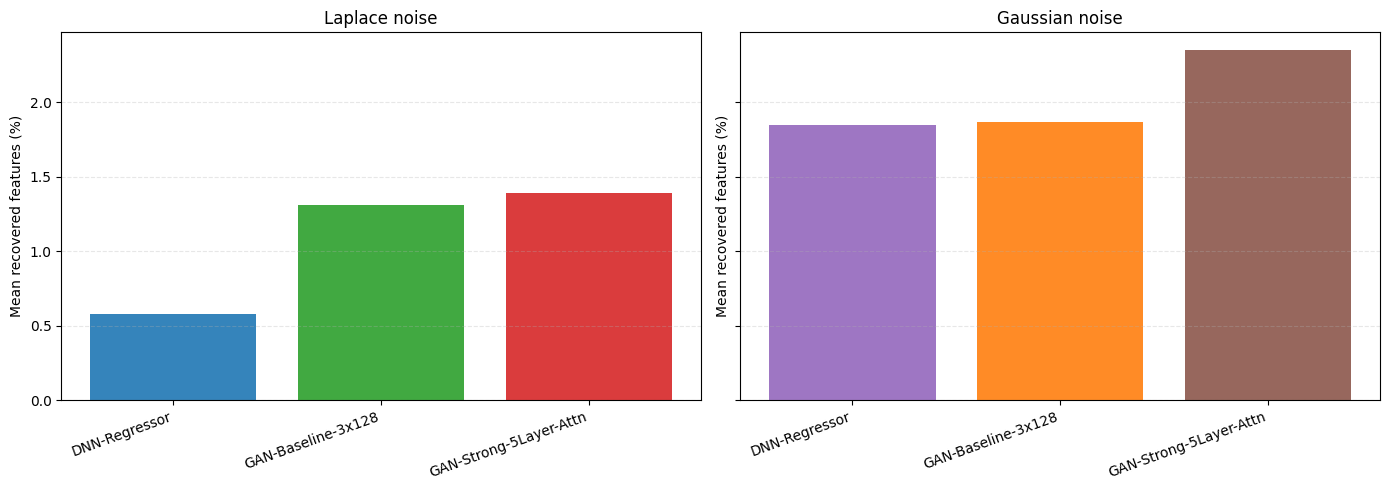

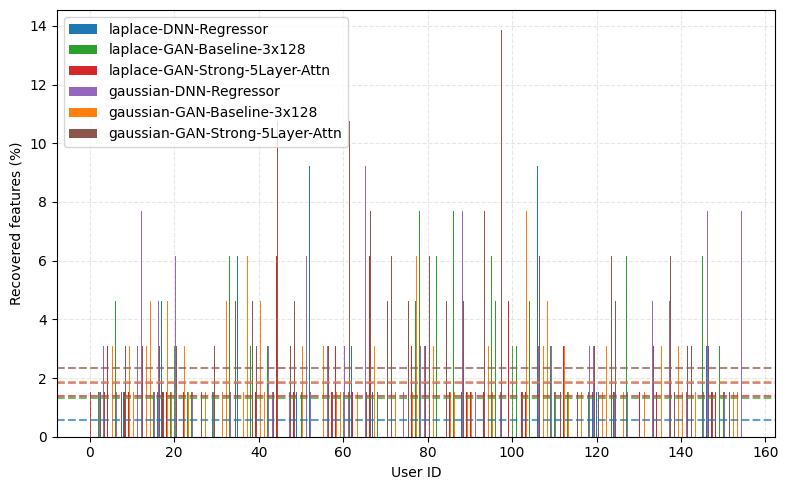

Saved summary CSV: c:\Users\mdmor\OneDrive - Concordia University of Edmonton\CUE\GitHub\ModelDataProtection\Voice_Dataset\reviewer_revision_outputs\reviewer_attack_summary_unknown_r.csv
Saved per-user CSV: c:\Users\mdmor\OneDrive - Concordia University of Edmonton\CUE\GitHub\ModelDataProtection\Voice_Dataset\reviewer_revision_outputs\reviewer_attack_per_user_unknown_r.csv
Saved summary plot: c:\Users\mdmor\OneDrive - Concordia University of Edmonton\CUE\GitHub\ModelDataProtection\Voice_Dataset\reviewer_revision_outputs\reviewer_attack_summary_known_r.png
Saved per-user plot: c:\Users\mdmor\OneDrive - Concordia University of Edmonton\CUE\GitHub\ModelDataProtection\Voice_Dataset\reviewer_revision_outputs\known_r_drawing.png

Reviewer-facing interpretation:
- gaussian: the stronger GAN produced higher mean recoverability than the original shallow GAN by 0.486 percentage points.
- laplace: the stronger GAN produced higher mean recoverability than the original shallow GAN by 0.079 percenta

In [106]:
def compute_recoverability(true_df: pd.DataFrame, recovered: np.ndarray, mechanism: str, model_name: str) -> pd.DataFrame:
    recovered_df = pd.DataFrame(recovered, columns=FEATURE_COLS)
    recovered_df["Label"] = true_df["Label"].to_numpy()
    rows = []

    for user_id in sorted(true_df["Label"].unique()):
        true_user = true_df[true_df["Label"] == user_id][FEATURE_COLS].to_numpy(dtype=np.float32)
        rec_user = recovered_df[recovered_df["Label"] == user_id][FEATURE_COLS].to_numpy(dtype=np.float32)

        passed = 0
        for col_idx in range(true_user.shape[1]):
            _, p_value = ks_2samp(true_user[:, col_idx], rec_user[:, col_idx])
            passed += int(p_value > CFG.alpha)

        rows.append({
            "Mechanism": mechanism,
            "Model": model_name,
            "Label": int(user_id),
            "RecoveredFeatures": int(passed),
            "RecoveredPercent": 100.0 * passed / true_user.shape[1],
        })

    return pd.DataFrame(rows)


def summarize_recoverability(per_user_df: pd.DataFrame) -> dict:
    return {
        "Mechanism": per_user_df["Mechanism"].iloc[0],
        "Model": per_user_df["Model"].iloc[0],
        "MeanRecoveredFeatures": float(per_user_df["RecoveredFeatures"].mean()),
        "MeanRecoveredPercent": float(per_user_df["RecoveredPercent"].mean()),
        "ProfilesWithAnyRecovery": int((per_user_df["RecoveredFeatures"] > 0).sum()),
        "MaxRecoveredFeatures": int(per_user_df["RecoveredFeatures"].max()),
    }


summary_rows = []
per_user_outputs = []
history_bank = {}

for mechanism, bundle in protected_sets.items():
    print()
    print(f"=== Running {mechanism.upper()} attack benchmark ===")
    #print(bundle["aux"].shape, auxiliary_df.shape)
    mlp_model, mlp_history = fit_inverse_mlp(bundle["aux"], auxiliary_df)
    baseline_g, baseline_d, baseline_history = fit_gan(bundle["aux"], auxiliary_df, BaselineGenerator, BaselineDiscriminator)
    strong_g, strong_d, strong_history = fit_gan(bundle["aux"], auxiliary_df, StrongGenerator, StrongDiscriminator)

    history_bank[(mechanism, "DNN")] = mlp_history
    history_bank[(mechanism, "BaselineGAN")] = baseline_history
    history_bank[(mechanism, "StrongGAN")] = strong_history

    recovered_map = {
        "DNN-Regressor": reconstruct_with_model(mlp_model, bundle["train"]),
        "GAN-Baseline-3x128": reconstruct_with_model(baseline_g, bundle["train"]),
        "GAN-Strong-5Layer-Attn": reconstruct_with_model(strong_g, bundle["train"]),
    }

    for model_name, recovered in recovered_map.items():
        per_user_df_model = compute_recoverability(training_df, recovered, mechanism=mechanism, model_name=model_name)
        per_user_outputs.append(per_user_df_model)
        summary_rows.append(summarize_recoverability(per_user_df_model))

summary_df = pd.DataFrame(summary_rows).sort_values(["Mechanism", "MeanRecoveredPercent", "Model"]).reset_index(drop=True)
per_user_df = pd.concat(per_user_outputs, ignore_index=True)

summary_path = OUTPUT_DIR / "reviewer_attack_summary_unknown_r.csv"
per_user_path = OUTPUT_DIR / "reviewer_attack_per_user_unknown_r.csv"
summary_df.to_csv(summary_path, index=False)
per_user_df.to_csv(per_user_path, index=False)

display(summary_df)

comparison = summary_df.pivot(index="Mechanism", columns="Model", values="MeanRecoveredPercent")
comparison["StrongMinusBaselineGAN"] = comparison["GAN-Strong-5Layer-Attn"] - comparison["GAN-Baseline-3x128"]
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {
    "laplace": {
        "DNN-Regressor": "#1f77b4",          # blue
        "GAN-Baseline-3x128": "#2ca02c",    # green
        "GAN-Strong-5Layer-Attn": "#d62728" # red
    },
    "gaussian": {
        "DNN-Regressor": "#9467bd",          # purple
        "GAN-Baseline-3x128": "#ff7f0e",    # orange
        "GAN-Strong-5Layer-Attn": "#8c564b" # brown
    }
}

for ax, mechanism in zip(axes, ["laplace", "gaussian"]):
    subset = summary_df[summary_df["Mechanism"] == mechanism].copy()
    x_pos = np.arange(len(subset))
    ax.bar(
        x_pos,
        subset["MeanRecoveredPercent"],
        #color=[colors[m] for m in subset["Model"]],
        color=[colors[mechanism][m] for m in subset["Model"]],
        alpha=0.9,
    )
    ax.set_title(f"{mechanism.capitalize()} noise")
    ax.set_ylabel("Mean recovered features (%)")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(subset["Model"], rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
summary_plot_path = OUTPUT_DIR / "reviewer_attack_summary_known_r.png"
plt.savefig(summary_plot_path, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 5), sharey=True)
bar_width=0.1
models = ["DNN-Regressor", "GAN-Baseline-3x128", "GAN-Strong-5Layer-Attn"]
mechanisms = ["laplace", "gaussian"]

labels = sorted(per_user_df["Label"].unique())
x = np.arange(len(labels))

for m_idx, mechanism in enumerate(mechanisms):
    subset = per_user_df[per_user_df["Mechanism"] == mechanism]

    for idx, model_name in enumerate(models):
        curve = subset[subset["Model"] == model_name].sort_values("Label")

        ax.bar(
            curve["Label"] + (m_idx * len(models) + idx) * bar_width,
            curve["RecoveredPercent"].values,
            width=bar_width,
            label=f"{mechanism}-{model_name}",
            #color=colors[model_name]
            color=colors[mechanism][model_name]
        )

        ax.axhline(
            y=curve["RecoveredPercent"].mean(),
            linestyle="--",
            #color=colors[model_name],
            color=colors[mechanism][model_name],
            alpha=0.7
        )

#ax.set_title("Per-user recoverability: Laplace vs Gaussian")
ax.set_xlabel("User ID")
ax.set_ylabel("Recovered features (%)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()


plt.tight_layout()
per_user_plot_path = OUTPUT_DIR / "known_r_drawing.png"
plt.savefig(per_user_plot_path, dpi=300, bbox_inches="tight")
plt.show()

for (mechanism, model_name), history_df in history_bank.items():
    history_df.to_csv(OUTPUT_DIR / f"history_{mechanism}_{model_name}.csv", index=False)

print("Saved summary CSV:", summary_path)
print("Saved per-user CSV:", per_user_path)
print("Saved summary plot:", summary_plot_path)
print("Saved per-user plot:", per_user_plot_path)
print()
print("Reviewer-facing interpretation:")
for mechanism in comparison.index:
    delta = comparison.loc[mechanism, "StrongMinusBaselineGAN"]
    direction = "higher" if delta > 0 else "lower or equal"
    print(f"- {mechanism}: the stronger GAN produced {direction} mean recoverability than the original shallow GAN by {delta:.3f} percentage points.")
print("If these deltas stay small, the privacy claim is not an artifact of a weak attack architecture.")